# Controle des acquis de la qualite No2
### Corally Ngov(2392143) et Lina Sadat(2378349)
---


## 3.2)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp

<Figure size 2160x720 with 0 Axes>

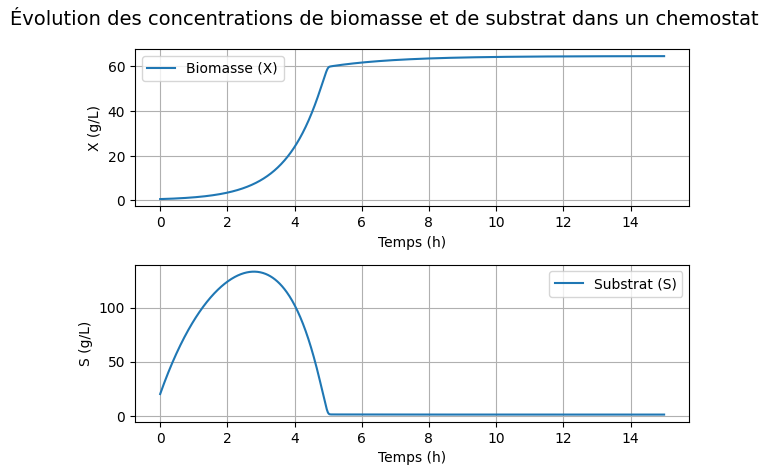

In [3]:
def bilans(t, x, p, u):
    #Variables d'état
    [X, S] = x
    #Paramètres
    [V, F0, Sin, mu_max, Ks, Yxs] = p
    #Equations
    mu = mu_max * S / (Ks + S)
    dX = -(F0/V) * X + mu * X
    dS = (F0/V) * (Sin - S) - (1/Yxs) * mu * X
    return [dX, dS]

#Conditions initiales
x0 = [0.5, 20]
p = [2.0, 1.0, 200, 1.5, 2.0, 0.325]
t_sim = [0, 15]
u0 = []

sim = solve_ivp(bilans, t_sim, x0, method = 'RK45', args = (p, u0), max_step = 0.01)


#Graphiques
plt.figure(figsize=(18, 6), dpi=120)
fig, axs = plt.subplots(nrows = 2, ncols = 1)
fig.suptitle('Évolution des concentrations de biomasse et de substrat dans un chemostat', fontsize=14)

axs[0].plot(sim.t, sim.y[0, :], label ='Biomasse (X)')
axs[0].set_xlabel('Temps (h)')
axs[0].set_ylabel('X (g/L)')
axs[0].legend()
axs[0].grid()

axs[1].plot(sim.t, sim.y[1, :], label ='Substrat (S)')
axs[1].set_xlabel('Temps (h)')
axs[1].set_ylabel('S (g/L)')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()




#### La courbe de biomasse augmente de manière exponentielle à partir de 2.5h ce qui est justifié par la concentration de substrat qui atteint son maximum. La courbe de substrat est parabolique ce qui est explicable par le fait qu'il faut une concentration minimale de substrat pour débuter la conversion en biomasse. À 5h, la concentration de substrat est nulle ce qui arrête la réaction. En effet, la concentration de biomasse à 5h va se stabiliser puisqu'il n'y plus de substrat.

## 3.3) a)


In [4]:
X_ss = sim.y[0, np.where(sim.t < 5)[0][-1]]
S_ss = sim.y[1, np.where(sim.t < 5)[0][-1]]

print(f"X* = {X_ss} g/L")
print(f"S* = {S_ss} g/L")

X* = 59.40854494790559 g/L
S* = 2.555461944332766 g/L


## b)


<Figure size 2160x720 with 0 Axes>

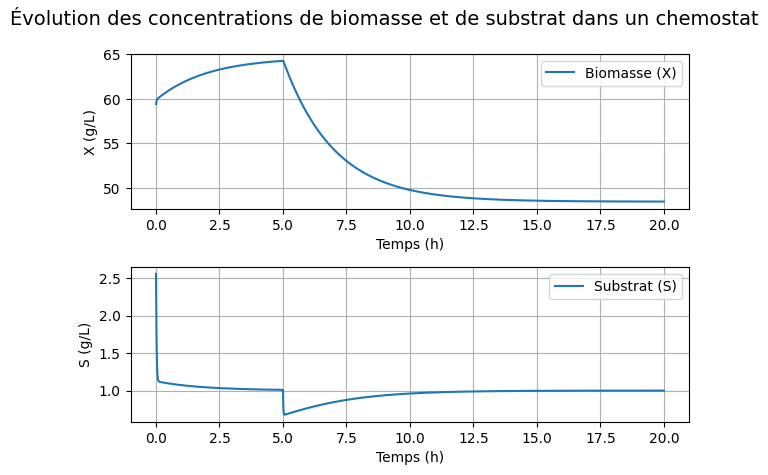

In [5]:
def bilans_changement_Sin(x, p, u):
    #Variables d'état
    [X, S] = x
    #Paramètres
    [V, F0, mu_max, Ks, Yxs] = p
    #Variable manipulée
    [Sin] = u
    #Equations
    mu = mu_max * S / (Ks + S)
    dX = -(F0/V) * X + mu * X
    dS = (F0/V) * (Sin - S) - (1/Yxs) * mu * X
    return [dX, dS]

def manip_Sin(t, x, p, t_changement):
    if t < t_changement:
        u = [200]
    else:
        u = [150]
    return bilans_changement_Sin(x, p, u)

#Conditions initiales
x0 = [X_ss, S_ss]
p = [2.0, 1.0, 1.5, 2.0, 0.325]
t_sim = [0, 20]
t_changement = 5

sim = solve_ivp(manip_Sin, t_sim, x0, method = 'RK45', args = (p, t_changement), max_step = 0.01)

#Graphiques
plt.figure(figsize=(18, 6), dpi=120)
fig, axs = plt.subplots(nrows = 2, ncols = 1)
fig.suptitle('Évolution des concentrations de biomasse et de substrat dans un chemostat', fontsize=14)

axs[0].plot(sim.t, sim.y[0, :], label ='Biomasse (X)')
axs[0].set_xlabel('Temps (h)')
axs[0].set_ylabel('X (g/L)')
axs[0].legend()
axs[0].grid()


axs[1].plot(sim.t, sim.y[1, :], label ='Substrat (S)')
axs[1].set_xlabel('Temps (h)')
axs[1].set_ylabel('S (g/L)')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()


#### On remarque que dès l’ajout de substrat à une concentration de 200 g/L, de la biomasse est formée. Sur le graphique de la biomasse, on observe une croissance jusqu’à la diminution de l’échelon de concentration de l’alimentation à t = 5 h. En effet, lorsque Sin passe de 200 g/L à 150 g/L, la concentration de biomasse diminue rapidement avant de se stabiliser autour de 20 g/L.

#### Pour le substrat, à t = 5 h, on voit clairement sur le graphique une diminution de la concentration, suivie d’une remontée qui se stabilise ensuite à environ 1 g/L.

### 3.4)

<Figure size 2160x720 with 0 Axes>

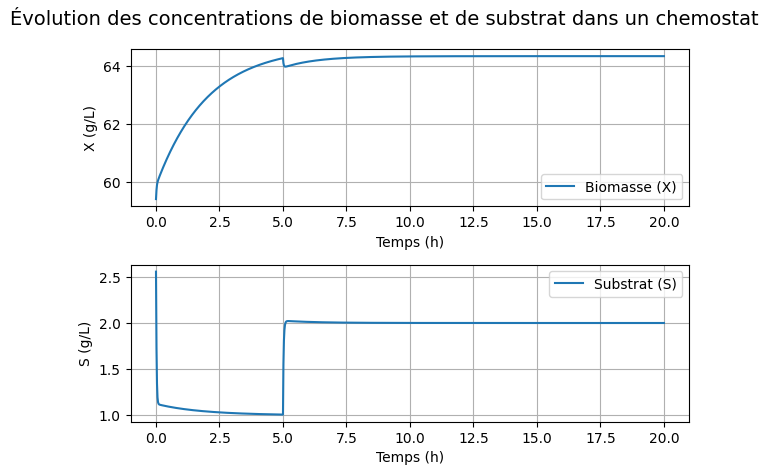

In [6]:
def bilans_changement_F1(x, p, u):
    #Variables d'état
    [X, S] = x
    #Paramètres
    [V, Sin,  mu_max, Ks, Yxs] = p
    #Variable manipulée
    [F1] = u
    #Equations
    mu = mu_max * S / (Ks + S)
    dX = -(F1/V) * X + mu * X
    dS = (F1/V) * (Sin - S) - (1/Yxs) * mu * X
    return [dX, dS]

F0 = 1.0
F1 = 1.5*F0

def manip_F0(t, x, p, t_changement):
    if t < t_changement:
        u = [F0]
    else:
        u = [F1]
    return bilans_changement_F1(x, p, u)

#Conditions initiales
x0 = [X_ss, S_ss]
p = [2.0, 200, 1.5, 2.0, 0.325]
t_sim = [0, 20]
t_changement = 5

sim = solve_ivp(manip_F0, t_sim, x0, method = 'RK45', args = (p, t_changement), max_step = 0.01)

#Graphiques
plt.figure(figsize=(18, 6), dpi=120)
fig, axs = plt.subplots(nrows = 2, ncols = 1)
fig.suptitle('Évolution des concentrations de biomasse et de substrat dans un chemostat', fontsize=14)

axs[0].plot(sim.t, sim.y[0, :], label ='Biomasse (X)')
axs[0].set_xlabel('Temps (h)')
axs[0].set_ylabel('X (g/L)')
axs[0].legend()
axs[0].grid()


axs[1].plot(sim.t, sim.y[1, :], label ='Substrat (S)')
axs[1].set_xlabel('Temps (h)')
axs[1].set_ylabel('S (g/L)')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()


#### L’augmentation du débit d’entrée du substrat, à concentration constante, entraîne d’abord une diminution de la concentration de biomasse. Par la suite, celle-ci remonte et se stabilise. Pour la concentration de substrat, on observe clairement qu’à t = 5 h, elle augmente puis se stabilise près de cette nouvelle concentration.

## 3.5)

In [10]:
import sympy as sp

X , S = sp.symbols('X S')
V, mu_max, Ks, Yxs = sp.symbols('V mu_max Ks Yxs')
F0, Sin = sp.symbols('F0 Sin')

mu = mu_max * S / (Ks + S)
dX = -(F0/V) * X + mu * X
dS = (F0/V) * (Sin - S) - (1/Yxs) * mu * X

f = sp.Matrix([dX, dS])
x = sp.Matrix([X, S])
u = sp.Matrix([Sin, F0])

mat_A = sp.simplify(f.jacobian(x))
mat_B = sp.simplify(f.jacobian(u))

print("Matrice A - symbolique =")
sp.pprint(mat_A)

print("\nMatrice B - symbolique =")
sp.pprint(mat_B)

valeurs_nums = {X: X_ss, S: S_ss,
                V: 2.0, mu_max: 1.5, Ks: 2.0, Yxs: 0.325,
                F0: 0, Sin: -50}

mat_A_num = mat_A.subs(valeurs_nums).evalf()
mat_B_num = mat_B.subs(valeurs_nums).evalf()

print("\nMatrice A - numérique =")
sp.pprint(mat_A_num)

print("\nMatrice B - numérique =")
sp.pprint(mat_B_num)
                



Matrice A - symbolique =
⎡-F₀⋅(Ks + S) + S⋅V⋅μₘₐₓ       Ks⋅X⋅μₘₐₓ      ⎤
⎢───────────────────────       ─────────      ⎥
⎢      V⋅(Ks + S)                      2      ⎥
⎢                              (Ks + S)       ⎥
⎢                                             ⎥
⎢       -S⋅μₘₐₓ             F₀     Ks⋅X⋅μₘₐₓ  ⎥
⎢     ────────────        - ── - ─────────────⎥
⎢     Yxs⋅(Ks + S)          V                2⎥
⎣                                Yxs⋅(Ks + S) ⎦

Matrice B - symbolique =
⎡      -X    ⎤
⎢0     ───   ⎥
⎢       V    ⎥
⎢            ⎥
⎢F₀  -S + Sin⎥
⎢──  ────────⎥
⎣V      V    ⎦

Matrice A - numérique =
⎡0.841449882216192  8.58826278232433 ⎤
⎢                                    ⎥
⎣-2.5890765606652   -26.4254239456133⎦

Matrice B - numérique =
⎡0  -29.7042724739528⎤
⎢                    ⎥
⎣0  -26.2777309721664⎦
